# Notebook 01 — Synthetic Project Delay Data Generator 

This notebook generates the synthetic benchmark and exports transparent documentation of:
- every predictor distribution and dependency;
- which settings are **researcher-defined simulation choices** versus literature-informed directions or deterministic derivations;
- the exact target coefficients and interaction rules;
- artificial prevalence construction, post-target variables, missingness, and reproducibility metadata;
- an alternative structural-generator specification used by Notebook 02 for robustness/ablation tests.

**Important interpretation:** none of the numerical distributions, coefficient magnitudes, thresholds, or rule weights are presented as empirical Saudi/Vision 2030 population parameters unless an external source is explicitly added in the manuscript. The dataset is a controlled methodological benchmark.


In [1]:
# =========================
# 0. Setup and Reproducibility
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

# Repository-root resolver: allows notebooks to run from the repository root
# or from the notebooks/ directory without changing output paths.
def _find_repo_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".project-root").exists():
            return candidate
    return current

REPO_ROOT = _find_repo_root()
PROJECT_DIR = REPO_ROOT / "project_delay_outputs"
DATA_DIR = PROJECT_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

N = 500000

## 1. Feature Design and Dependency Structure

The dataset includes project baseline features, project-management process features, risk-source features, and digital-transformation features.

The features are intentionally separated into:

- **Immutable descriptive fields:** project type, sector, region, contract type, procurement method, and complexity level.
- **Semi-controllable planning fields:** planned budget, planned duration, and schedule buffer.
- **Controllable management fields:** communication, coordination, BIM/AI adoption, resource availability, approval-cycle efficiency, contractor capability, and payment/procurement indicators.
- **External risk fields:** weather, permit risk, inflation risk, site-condition risk, and force majeure.

Most management scores are generated independently from bounded distributions. Explicit dependencies are introduced where project-management logic requires them. In particular, planned duration and budget depend on complexity; design changes, change requests, procurement lead time, and safety incidents vary with complexity; approval duration is the product of the number of authorities and approval time per authority; and the external-risk score is a weighted composite of external-risk indicators.


In [2]:
# =========================
# 1. Generate Base Features
# =========================
project_types = ["Construction", "Infrastructure", "Transportation", "Utilities", "Oil & Gas", "Power Plant", "IT/Digital"]
sectors = ["Public", "Private", "Semi-Government"]
regions = ["Riyadh", "Jeddah", "Dammam", "Makkah", "Madinah", "NEOM/Tabuk", "Other"]
contract_types = ["Lump Sum", "EPC", "Design-Build", "Unit Rate", "Time & Material"]
procurement_methods = ["Competitive Tender", "Direct Award", "Framework Agreement", "Public Tender"]
complexity_levels = ["Low", "Medium", "High", "Mega"]

df = pd.DataFrame({
    "Project_ID": [f"P-{i:05d}" for i in range(1, N + 1)],
    "Project_Type": rng.choice(project_types, N, p=[0.24, 0.20, 0.12, 0.12, 0.10, 0.10, 0.12]),
    "Sector": rng.choice(sectors, N, p=[0.48, 0.32, 0.20]),
    "Region": rng.choice(regions, N),
    "Contract_Type": rng.choice(contract_types, N, p=[0.24, 0.22, 0.18, 0.22, 0.14]),
    "Procurement_Method": rng.choice(procurement_methods, N, p=[0.42, 0.12, 0.16, 0.30]),
    "Complexity_Level": rng.choice(complexity_levels, N, p=[0.18, 0.42, 0.30, 0.10]),
})

complexity_map = {"Low": 1, "Medium": 2, "High": 3, "Mega": 4}
df["Complexity_Score"] = df["Complexity_Level"].map(complexity_map)

# Planned duration and budget increase with complexity.
df["Planned_Duration_Days"] = (
    rng.normal(120, 35, N)
    + df["Complexity_Score"] * rng.normal(70, 18, N)
    + rng.gamma(2, 18, N)
).clip(45, 900).round().astype(int)

df["Planned_Budget_Million"] = (
    rng.lognormal(mean=2.1, sigma=0.75, size=N)
    * df["Complexity_Score"]
).clip(1, 850).round(2)

# Schedule buffer as % of planned duration.
df["Schedule_Buffer_Percent"] = rng.beta(2, 6, N) * 25

In [3]:
# =========================
# 2. Generate Risk and Management Features
# =========================
def clipped_normal(mean, sd, low, high, size=N):
    return np.clip(rng.normal(mean, sd, size), low, high)

# Scores are mostly 1 to 10 unless stated otherwise.
df["Scope_Clarity_Score"] = clipped_normal(7.0, 1.8, 1, 10).round(1)
df["Stakeholder_Communication_Score"] = clipped_normal(6.7, 1.9, 1, 10).round(1)
df["Coordination_Score"] = clipped_normal(6.6, 1.8, 1, 10).round(1)
df["Contractor_Experience_Score"] = clipped_normal(6.8, 2.0, 1, 10).round(1)
df["Project_Manager_Experience_Years"] = clipped_normal(8, 4, 0, 30).round(1)
df["Resource_Availability_Score"] = clipped_normal(6.8, 1.7, 1, 10).round(1)
df["Labor_Productivity_Score"] = clipped_normal(6.6, 1.8, 1, 10).round(1)
df["Equipment_Availability_Score"] = clipped_normal(7.0, 1.6, 1, 10).round(1)
df["Supplier_Reliability_Score"] = clipped_normal(6.9, 1.7, 1, 10).round(1)
df["Contractor_Financial_Stability"] = clipped_normal(7.0, 1.8, 1, 10).round(1)
df["Owner_Decision_Speed_Score"] = clipped_normal(6.6, 1.9, 1, 10).round(1)

# Digital maturity.
df["BIM_Adoption_Level"] = rng.choice([0, 1, 2, 3], N, p=[0.35, 0.28, 0.25, 0.12])  # 0 None, 1 Basic, 2 Moderate, 3 Advanced
df["AI_Tools_Adoption_Level"] = rng.choice([0, 1, 2, 3], N, p=[0.48, 0.26, 0.18, 0.08])

# Approval process.
df["Authorities_Involved"] = rng.integers(1, 7, N)
df["Approval_Per_Authority_Days"] = rng.integers(2, 16, N)
df["Approval_Duration_Days"] = df["Authorities_Involved"] * df["Approval_Per_Authority_Days"]

# Change, design, procurement and quality indicators.
df["Design_Change_Count"] = rng.poisson(lam=1.3 + 0.7 * df["Complexity_Score"], size=N).clip(0, 15)
df["Change_Request_Count"] = rng.poisson(lam=0.9 + 0.55 * df["Complexity_Score"], size=N).clip(0, 12)
df["Procurement_Lead_Time_Days"] = (rng.normal(25, 10, N) + 6 * df["Complexity_Score"]).clip(5, 120).round().astype(int)
df["Payment_Delay_Days"] = rng.gamma(shape=1.4, scale=7.0, size=N).clip(0, 90).round().astype(int)
df["Quality_Defect_Rate"] = (rng.beta(2, 12, N) * 20).round(2)
df["Safety_Incident_Count"] = rng.poisson(lam=0.15 + 0.12 * df["Complexity_Score"], size=N).clip(0, 8)

# External risks: 1 low to 10 high.
df["Weather_Risk_Score"] = clipped_normal(4.5, 2.1, 1, 10).round(1)
df["Permit_Risk_Score"] = clipped_normal(4.8, 2.2, 1, 10).round(1)
df["Inflation_Risk_Score"] = clipped_normal(4.7, 2.0, 1, 10).round(1)
df["Site_Condition_Risk_Score"] = clipped_normal(4.6, 2.2, 1, 10).round(1)
df["Force_Majeure_Flag"] = rng.binomial(1, 0.055, N)
df["External_Risk_Score"] = (
    0.27 * df["Weather_Risk_Score"]
    + 0.30 * df["Permit_Risk_Score"]
    + 0.22 * df["Inflation_Risk_Score"]
    + 0.21 * df["Site_Condition_Risk_Score"]
    + 1.5 * df["Force_Majeure_Flag"]
).clip(1, 10).round(2)

### 2.1 Generation Specification

The following table documents the exact baseline generation method used by the code. This table is intended to support reproducibility and can be adapted directly into the manuscript's synthetic-data methodology section.


In [4]:
generation_specification = pd.DataFrame([
    ["Project_Type", "Categorical", "Categorical choice", "Construction 0.24; Infrastructure 0.20; Transportation 0.12; Utilities 0.12; Oil & Gas 0.10; Power Plant 0.10; IT/Digital 0.12"],
    ["Sector", "Categorical", "Categorical choice", "Public 0.48; Private 0.32; Semi-Government 0.20"],
    ["Region", "Categorical", "Uniform categorical choice", "Riyadh; Jeddah; Dammam; Makkah; Madinah; NEOM/Tabuk; Other"],
    ["Contract_Type", "Categorical", "Categorical choice", "Lump Sum 0.24; EPC 0.22; Design-Build 0.18; Unit Rate 0.22; Time & Material 0.14"],
    ["Procurement_Method", "Categorical", "Categorical choice", "Competitive Tender 0.42; Direct Award 0.12; Framework Agreement 0.16; Public Tender 0.30"],
    ["Complexity_Level", "Categorical", "Categorical choice", "Low 0.18; Medium 0.42; High 0.30; Mega 0.10"],
    ["Complexity_Score", "Numerical", "Deterministic mapping", "Low=1; Medium=2; High=3; Mega=4"],
    ["Planned_Duration_Days", "Numerical", "Normal(120,35) + Complexity_Score*Normal(70,18) + Gamma(2,18)", "Clipped 45–900 days; rounded integer"],
    ["Planned_Budget_Million", "Numerical", "Lognormal(mean=2.1,sigma=0.75)*Complexity_Score", "Clipped 1–850; rounded 2 decimals"],
    ["Schedule_Buffer_Percent", "Numerical", "Beta(2,6)*25", "Approximately 0–25%"],
    ["Scope_Clarity_Score", "Numerical", "Normal(7.0,1.8)", "Clipped 1–10; 1 decimal"],
    ["Stakeholder_Communication_Score", "Numerical", "Normal(6.7,1.9)", "Clipped 1–10; 1 decimal"],
    ["Coordination_Score", "Numerical", "Normal(6.6,1.8)", "Clipped 1–10; 1 decimal"],
    ["Contractor_Experience_Score", "Numerical", "Normal(6.8,2.0)", "Clipped 1–10; 1 decimal"],
    ["Project_Manager_Experience_Years", "Numerical", "Normal(8,4)", "Clipped 0–30 years; 1 decimal"],
    ["Resource_Availability_Score", "Numerical", "Normal(6.8,1.7)", "Clipped 1–10; 1 decimal"],
    ["Labor_Productivity_Score", "Numerical", "Normal(6.6,1.8)", "Clipped 1–10; 1 decimal"],
    ["Equipment_Availability_Score", "Numerical", "Normal(7.0,1.6)", "Clipped 1–10; 1 decimal"],
    ["Supplier_Reliability_Score", "Numerical", "Normal(6.9,1.7)", "Clipped 1–10; 1 decimal"],
    ["Contractor_Financial_Stability", "Numerical", "Normal(7.0,1.8)", "Clipped 1–10; 1 decimal"],
    ["Owner_Decision_Speed_Score", "Numerical", "Normal(6.6,1.9)", "Clipped 1–10; 1 decimal"],
    ["BIM_Adoption_Level", "Ordinal", "Categorical choice", "0:0.35; 1:0.28; 2:0.25; 3:0.12"],
    ["AI_Tools_Adoption_Level", "Ordinal", "Categorical choice", "0:0.48; 1:0.26; 2:0.18; 3:0.08"],
    ["Authorities_Involved", "Numerical", "Discrete uniform integers", "1–6"],
    ["Approval_Per_Authority_Days", "Numerical", "Discrete uniform integers", "2–15 days"],
    ["Approval_Duration_Days", "Numerical", "Authorities_Involved × Approval_Per_Authority_Days", "Derived"],
    ["Design_Change_Count", "Numerical", "Poisson(lambda=1.3+0.7*Complexity_Score)", "Clipped 0–15"],
    ["Change_Request_Count", "Numerical", "Poisson(lambda=0.9+0.55*Complexity_Score)", "Clipped 0–12"],
    ["Procurement_Lead_Time_Days", "Numerical", "Normal(25,10)+6*Complexity_Score", "Clipped 5–120 days; rounded integer"],
    ["Payment_Delay_Days", "Numerical", "Gamma(shape=1.4, scale=7.0)", "Clipped 0–90 days; rounded integer"],
    ["Quality_Defect_Rate", "Numerical", "Beta(2,12)*20", "Approximately 0–20; rounded 2 decimals"],
    ["Safety_Incident_Count", "Numerical", "Poisson(lambda=0.15+0.12*Complexity_Score)", "Clipped 0–8"],
    ["Weather_Risk_Score", "Numerical", "Normal(4.5,2.1)", "Clipped 1–10; 1 decimal"],
    ["Permit_Risk_Score", "Numerical", "Normal(4.8,2.2)", "Clipped 1–10; 1 decimal"],
    ["Inflation_Risk_Score", "Numerical", "Normal(4.7,2.0)", "Clipped 1–10; 1 decimal"],
    ["Site_Condition_Risk_Score", "Numerical", "Normal(4.6,2.2)", "Clipped 1–10; 1 decimal"],
    ["Force_Majeure_Flag", "Binary", "Bernoulli(p=0.055)", "0 or 1"],
    ["External_Risk_Score", "Numerical", "0.27*Weather + 0.30*Permit + 0.22*Inflation + 0.21*Site + 1.5*Force_Majeure", "Clipped 1–10; rounded 2 decimals"],
], columns=["Variable", "Type", "Generation_Method", "Range_or_Categories"])

display(generation_specification)


,Variable,Type,Generation_Method,Range_or_Categories
0,Project_Type,Categorical,Categorical choice,Construction 0.24; Infrastructure 0.20; Transp...
1,Sector,Categorical,Categorical choice,Public 0.48; Private 0.32; Semi-Government 0.20
2,Region,Categorical,Uniform categorical choice,Riyadh; Jeddah; Dammam; Makkah; Madinah; NEOM/...
3,Contract_Type,Categorical,Categorical choice,Lump Sum 0.24; EPC 0.22; Design-Build 0.18; Un...
4,Procurement_Method,Categorical,Categorical choice,Competitive Tender 0.42; Direct Award 0.12; Fr...
5,Complexity_Level,Categorical,Categorical choice,Low 0.18; Medium 0.42; High 0.30; Mega 0.10
6,Complexity_Score,Numerical,Deterministic mapping,Low=1; Medium=2; High=3; Mega=4
7,Planned_Duration_Days,Numerical,"Normal(120,35) + Complexity_Score*Normal(70,18...",Clipped 45–900 days; rounded integer
8,Planned_Budget_Million,Numerical,"Lognormal(mean=2.1,sigma=0.75)*Complexity_Score",Clipped 1–850; rounded 2 decimals
9,Schedule_Buffer_Percent,Numerical,"Beta(2,6)*25",Approximately 0–25%


In [5]:
# =========================
# 2.2 Evidence Basis / Simulation-Rationale Classification
# =========================
# The reviewer requested a clear distinction between empirical evidence,
# literature-informed direction, expert-informed assumptions, and
# researcher-defined simulation choices.
#
# No parameter below was estimated from real Saudi/Vision 2030 project data.
# Numerical distributions, category probabilities, clipping ranges, and
# coefficient magnitudes are therefore explicitly labeled as simulation choices.

derived_features = {
    "Complexity_Score",
    "Approval_Duration_Days",
    "External_Risk_Score",
}

literature_direction_features = {
    "Planned_Duration_Days",
    "Planned_Budget_Million",
    "Schedule_Buffer_Percent",
    "Scope_Clarity_Score",
    "Stakeholder_Communication_Score",
    "Coordination_Score",
    "Contractor_Experience_Score",
    "Project_Manager_Experience_Years",
    "Resource_Availability_Score",
    "Labor_Productivity_Score",
    "Equipment_Availability_Score",
    "Supplier_Reliability_Score",
    "Contractor_Financial_Stability",
    "Owner_Decision_Speed_Score",
    "BIM_Adoption_Level",
    "AI_Tools_Adoption_Level",
    "Authorities_Involved",
    "Approval_Per_Authority_Days",
    "Design_Change_Count",
    "Change_Request_Count",
    "Procurement_Lead_Time_Days",
    "Payment_Delay_Days",
    "Quality_Defect_Rate",
    "Safety_Incident_Count",
    "Weather_Risk_Score",
    "Permit_Risk_Score",
    "Inflation_Risk_Score",
    "Site_Condition_Risk_Score",
    "Force_Majeure_Flag",
}

def evidence_basis_for_variable(variable):
    if variable in derived_features:
        return "Deterministic derived relationship"
    if variable in literature_direction_features:
        return "Literature-informed direction; researcher-defined numeric simulation setting"
    return "Researcher-defined simulation choice"

def rationale_for_variable(variable):
    if variable == "Complexity_Score":
        return "Ordinal numeric encoding of the simulated complexity category."
    if variable == "Approval_Duration_Days":
        return "Derived to preserve the logical relationship between authority count and per-authority review time."
    if variable == "External_Risk_Score":
        return "Composite synthetic indicator combining external-risk dimensions; component weights are simulation choices."
    if variable in {"Planned_Duration_Days", "Planned_Budget_Million"}:
        return "Generated to increase with simulated complexity; functional form and magnitude are simulation assumptions."
    if variable in {"Design_Change_Count", "Change_Request_Count", "Procurement_Lead_Time_Days", "Safety_Incident_Count"}:
        return "Generated conditionally on complexity to create plausible dependency structure; parameters are simulation assumptions."
    if variable in literature_direction_features:
        return "Included because the literature identifies the construct as relevant to project delay/risk; the numerical distribution/range is not an empirical population estimate."
    return "Used to diversify the controlled synthetic benchmark; probabilities/ranges are researcher-defined."

generation_specification["Evidence_Basis"] = generation_specification["Variable"].map(
    evidence_basis_for_variable
)
generation_specification["Rationale"] = generation_specification["Variable"].map(
    rationale_for_variable
)
generation_specification["Estimated_From_Real_Project_Data"] = False
generation_specification["Citation_Note"] = generation_specification["Variable"].map(
    lambda v: (
        "Use direct manuscript citation for the expected relationship where claimed; "
        "do not cite the numeric simulation setting as empirical unless a source directly supports it."
    )
)

display(generation_specification)


,Variable,Type,Generation_Method,Range_or_Categories,Evidence_Basis,Rationale,Estimated_From_Real_Project_Data,Citation_Note
0,Project_Type,Categorical,Categorical choice,Construction 0.24; Infrastructure 0.20; Transp...,Researcher-defined simulation choice,Used to diversify the controlled synthetic ben...,False,Use direct manuscript citation for the expecte...
1,Sector,Categorical,Categorical choice,Public 0.48; Private 0.32; Semi-Government 0.20,Researcher-defined simulation choice,Used to diversify the controlled synthetic ben...,False,Use direct manuscript citation for the expecte...
2,Region,Categorical,Uniform categorical choice,Riyadh; Jeddah; Dammam; Makkah; Madinah; NEOM/...,Researcher-defined simulation choice,Used to diversify the controlled synthetic ben...,False,Use direct manuscript citation for the expecte...
3,Contract_Type,Categorical,Categorical choice,Lump Sum 0.24; EPC 0.22; Design-Build 0.18; Un...,Researcher-defined simulation choice,Used to diversify the controlled synthetic ben...,False,Use direct manuscript citation for the expecte...
4,Procurement_Method,Categorical,Categorical choice,Competitive Tender 0.42; Direct Award 0.12; Fr...,Researcher-defined simulation choice,Used to diversify the controlled synthetic ben...,False,Use direct manuscript citation for the expecte...
5,Complexity_Level,Categorical,Categorical choice,Low 0.18; Medium 0.42; High 0.30; Mega 0.10,Researcher-defined simulation choice,Used to diversify the controlled synthetic ben...,False,Use direct manuscript citation for the expecte...
6,Complexity_Score,Numerical,Deterministic mapping,Low=1; Medium=2; High=3; Mega=4,Deterministic derived relationship,Ordinal numeric encoding of the simulated comp...,False,Use direct manuscript citation for the expecte...
7,Planned_Duration_Days,Numerical,"Normal(120,35) + Complexity_Score*Normal(70,18...",Clipped 45–900 days; rounded integer,Literature-informed direction; researcher-defi...,Generated to increase with simulated complexit...,False,Use direct manuscript citation for the expecte...
8,Planned_Budget_Million,Numerical,"Lognormal(mean=2.1,sigma=0.75)*Complexity_Score",Clipped 1–850; rounded 2 decimals,Literature-informed direction; researcher-defi...,Generated to increase with simulated complexit...,False,Use direct manuscript citation for the expecte...
9,Schedule_Buffer_Percent,Numerical,"Beta(2,6)*25",Approximately 0–25%,Literature-informed direction; researcher-defi...,Included because the literature identifies the...,False,Use direct manuscript citation for the expecte...


## 3. Rule-Based Delay Logic and Synthetic Target Construction

The target is generated from three components:

1. a continuous weighted score based on project features;
2. additive rule-based adjustments representing specific high-risk and risk-reducing combinations; and
3. a Gaussian noise term, \(\epsilon \sim N(0, 0.45^2)\), to prevent the target from being completely deterministic.

The resulting latent score is transformed with the logistic sigmoid function. The binary target is then defined using the median synthetic delay probability from the baseline dataset, producing an approximately balanced classification problem.

> The rule weights and coefficients below are assumptions of the synthetic generator informed by project-management logic and the literature. They are not estimated causal effects from real Saudi or Vision 2030 project data.


In [6]:
# =========================
# 3. Domain Rules and Target Generation
# =========================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

rule_score = pd.Series(0.0, index=df.index)

# Risk-increasing rules.
rule_score += np.where((df["Authorities_Involved"] > 4) & (df["Approval_Duration_Days"] > 35), 0.85, 0)
rule_score += np.where((df["Design_Change_Count"] >= 5) & (df["Scope_Clarity_Score"] < 6), 0.90, 0)
rule_score += np.where((df["Stakeholder_Communication_Score"] < 5) & (df["Coordination_Score"] < 5), 0.80, 0)
rule_score += np.where((df["Resource_Availability_Score"] < 5) | (df["Labor_Productivity_Score"] < 5), 0.65, 0)
rule_score += np.where((df["Supplier_Reliability_Score"] < 5) & (df["Procurement_Lead_Time_Days"] > 45), 0.70, 0)
rule_score += np.where((df["Contractor_Financial_Stability"] < 5) & (df["Payment_Delay_Days"] > 20), 0.75, 0)
rule_score += np.where((df["External_Risk_Score"] > 7) | (df["Force_Majeure_Flag"] == 1), 0.95, 0)
rule_score += np.where((df["Schedule_Buffer_Percent"] < 5) & (df["Complexity_Score"] >= 3), 0.65, 0)

# Risk-reducing rules.
rule_score -= np.where((df["BIM_Adoption_Level"] >= 2) & (df["Coordination_Score"] >= 7), 0.45, 0)
rule_score -= np.where((df["AI_Tools_Adoption_Level"] >= 2) & (df["Project_Manager_Experience_Years"] >= 8), 0.35, 0)
rule_score -= np.where((df["Schedule_Buffer_Percent"] >= 12) & (df["Scope_Clarity_Score"] >= 7), 0.35, 0)

# Continuous weighted score.
linear_score = (
    -2.40
    + 0.34 * df["Complexity_Score"]
    + 0.015 * (df["Planned_Duration_Days"] / 10)
    + 0.020 * np.log1p(df["Planned_Budget_Million"])
    + 0.10 * df["Design_Change_Count"]
    + 0.09 * df["Change_Request_Count"]
    + 0.012 * df["Approval_Duration_Days"]
    + 0.012 * df["Procurement_Lead_Time_Days"]
    + 0.018 * df["Payment_Delay_Days"]
    + 0.11 * df["External_Risk_Score"]
    + 0.06 * df["Quality_Defect_Rate"]
    + 0.18 * df["Safety_Incident_Count"]
    - 0.12 * df["Scope_Clarity_Score"]
    - 0.10 * df["Stakeholder_Communication_Score"]
    - 0.09 * df["Coordination_Score"]
    - 0.08 * df["Contractor_Experience_Score"]
    - 0.08 * df["Resource_Availability_Score"]
    - 0.07 * df["Labor_Productivity_Score"]
    - 0.06 * df["Equipment_Availability_Score"]
    - 0.06 * df["Supplier_Reliability_Score"]
    - 0.06 * df["Contractor_Financial_Stability"]
    - 0.05 * df["Owner_Decision_Speed_Score"]
    - 0.035 * df["Schedule_Buffer_Percent"]
    - 0.18 * df["BIM_Adoption_Level"]
    - 0.12 * df["AI_Tools_Adoption_Level"]
    + rule_score
    + rng.normal(0, 0.45, N)
)

df["Delay_Probability_True"] = sigmoid(linear_score).round(4)
balanced_threshold = df["Delay_Probability_True"].median()

df["Delayed"] = np.where(
    df["Delay_Probability_True"] >= balanced_threshold,
    1,
    0
)

print("Balanced threshold:", round(balanced_threshold, 4))
print(df["Delayed"].value_counts())
print(df["Delayed"].value_counts(normalize=True).round(4))

# Risk level derived from true probability.
low_threshold = df["Delay_Probability_True"].quantile(1/3)
high_threshold = df["Delay_Probability_True"].quantile(2/3)

df["Delay_Risk_Level"] = pd.cut(
    df["Delay_Probability_True"],
    bins=[-0.001, low_threshold, high_threshold, 1.001],
    labels=["Low", "Medium", "High"],
    include_lowest=True
).astype(str)

print("Low threshold:", round(low_threshold, 4))
print("High threshold:", round(high_threshold, 4))

print("\nDelay risk level counts:")
print(df["Delay_Risk_Level"].value_counts())

print("\nDelay risk level percentages:")
print((df["Delay_Risk_Level"].value_counts(normalize=True) * 100).round(2))

# Simulate actual duration for analysis, not as a model input target leakage feature.
overrun_ratio = np.where(
    df["Delayed"] == 1,
    rng.normal(0.22, 0.14, N).clip(0.02, 0.90),
    rng.normal(-0.03, 0.06, N).clip(-0.20, 0.08)
)
df["Actual_Duration_Days"] = (df["Planned_Duration_Days"] * (1 + overrun_ratio)).round().astype(int)
df["Time_Overrun_Percent"] = ((df["Actual_Duration_Days"] - df["Planned_Duration_Days"]) / df["Planned_Duration_Days"] * 100).round(2)
df["Rule_Score"] = rule_score.round(3)

df.head()

Balanced threshold: 0.016
Delayed
1    250422
0    249578
Name: count, dtype: int64
Delayed
1    0.5008
0    0.4992
Name: proportion, dtype: float64
Low threshold: 0.0088
High threshold: 0.0301

Delay risk level counts:
Delay_Risk_Level
Low       168120
High      166270
Medium    165610
Name: count, dtype: int64

Delay risk level percentages:
Delay_Risk_Level
Low       33.62
High      33.25
Medium    33.12
Name: proportion, dtype: float64


,Project_ID,Project_Type,Sector,Region,Contract_Type,Procurement_Method,Complexity_Level,Complexity_Score,Planned_Duration_Days,Planned_Budget_Million,...,Inflation_Risk_Score,Site_Condition_Risk_Score,Force_Majeure_Flag,External_Risk_Score,Delay_Probability_True,Delayed,Delay_Risk_Level,Actual_Duration_Days,Time_Overrun_Percent,Rule_Score
0,P-00001,Oil & Gas,Public,Makkah,EPC,Public Tender,Medium,2,264,18.54,...,6.4,1.0,0,4.69,0.0104,0,Medium,222,-15.91,0.85
1,P-00002,Infrastructure,Public,Madinah,Lump Sum,Public Tender,Medium,2,225,5.60,...,7.6,2.2,0,5.84,0.0293,1,Medium,284,26.22,0.00
2,P-00003,Power Plant,Semi-Government,NEOM/Tabuk,EPC,Competitive Tender,Medium,2,360,28.65,...,1.2,7.6,0,5.03,0.0085,0,Low,340,-5.56,0.00
3,P-00004,Oil & Gas,Private,Makkah,Time & Material,Direct Award,Medium,2,308,6.19,...,4.5,5.2,0,4.11,0.0180,1,Medium,382,24.03,0.00
4,P-00005,Construction,Private,NEOM/Tabuk,Design-Build,Public Tender,High,3,227,13.36,...,5.2,2.4,0,5.04,0.0295,1,Medium,243,7.05,0.65


### 3.1 Exact Target-Generation Specification

For each synthetic project, the latent delay score \(z\) is:

\[
\begin{aligned}
z = &-2.40
+0.34C
+0.015(D/10)
+0.020\ln(1+B)
+0.10DC
+0.09CR
+0.012AD \\
&+0.012PL
+0.018PD
+0.11ER
+0.06QD
+0.18SI
-0.12SC
-0.10COM
-0.09COO \\
&-0.08CE
-0.08RA
-0.07LP
-0.06EA
-0.06SR
-0.06FS
-0.05ODS
-0.035SB \\
&-0.18BIM
-0.12AI
+R
+\epsilon ,
\end{aligned}
\]

where \(R\) is the rule-based adjustment and \(\epsilon \sim N(0,0.45^2)\). The synthetic delay probability is

\[
p=\frac{1}{1+e^{-z}}.
\]

`Delay_Probability_True` is \(p\) rounded to four decimal places. For the baseline run (`SEED=42`, `N=500000`), the median threshold printed by the notebook is **0.0160**. `Delayed=1` when the rounded probability is greater than or equal to this threshold and `0` otherwise. The one-third and two-thirds probability quantiles used for the three risk levels are **0.0088** and **0.0301**, respectively, in the stored baseline run.

The symbols correspond directly to the feature names and coefficients listed in the next table.


In [7]:
continuous_weights = pd.DataFrame([
    ["Intercept", "-2.40"],
    ["Complexity_Score", "+0.34"],
    ["Planned_Duration_Days / 10", "+0.015"],
    ["log1p(Planned_Budget_Million)", "+0.020"],
    ["Design_Change_Count", "+0.10"],
    ["Change_Request_Count", "+0.09"],
    ["Approval_Duration_Days", "+0.012"],
    ["Procurement_Lead_Time_Days", "+0.012"],
    ["Payment_Delay_Days", "+0.018"],
    ["External_Risk_Score", "+0.11"],
    ["Quality_Defect_Rate", "+0.06"],
    ["Safety_Incident_Count", "+0.18"],
    ["Scope_Clarity_Score", "-0.12"],
    ["Stakeholder_Communication_Score", "-0.10"],
    ["Coordination_Score", "-0.09"],
    ["Contractor_Experience_Score", "-0.08"],
    ["Resource_Availability_Score", "-0.08"],
    ["Labor_Productivity_Score", "-0.07"],
    ["Equipment_Availability_Score", "-0.06"],
    ["Supplier_Reliability_Score", "-0.06"],
    ["Contractor_Financial_Stability", "-0.06"],
    ["Owner_Decision_Speed_Score", "-0.05"],
    ["Schedule_Buffer_Percent", "-0.035"],
    ["BIM_Adoption_Level", "-0.18"],
    ["AI_Tools_Adoption_Level", "-0.12"],
], columns=["Term", "Coefficient"])

rule_adjustments = pd.DataFrame([
    ["Authorities_Involved > 4 AND Approval_Duration_Days > 35", "+0.85"],
    ["Design_Change_Count >= 5 AND Scope_Clarity_Score < 6", "+0.90"],
    ["Stakeholder_Communication_Score < 5 AND Coordination_Score < 5", "+0.80"],
    ["Resource_Availability_Score < 5 OR Labor_Productivity_Score < 5", "+0.65"],
    ["Supplier_Reliability_Score < 5 AND Procurement_Lead_Time_Days > 45", "+0.70"],
    ["Contractor_Financial_Stability < 5 AND Payment_Delay_Days > 20", "+0.75"],
    ["External_Risk_Score > 7 OR Force_Majeure_Flag == 1", "+0.95"],
    ["Schedule_Buffer_Percent < 5 AND Complexity_Score >= 3", "+0.65"],
    ["BIM_Adoption_Level >= 2 AND Coordination_Score >= 7", "-0.45"],
    ["AI_Tools_Adoption_Level >= 2 AND Project_Manager_Experience_Years >= 8", "-0.35"],
    ["Schedule_Buffer_Percent >= 12 AND Scope_Clarity_Score >= 7", "-0.35"],
], columns=["Condition", "Rule_Adjustment"])

display(continuous_weights)
display(rule_adjustments)


,Term,Coefficient
0,Intercept,-2.40
1,Complexity_Score,+0.34
2,Planned_Duration_Days / 10,+0.015
3,log1p(Planned_Budget_Million),+0.020
4,Design_Change_Count,+0.10
5,Change_Request_Count,+0.09
6,Approval_Duration_Days,+0.012
7,Procurement_Lead_Time_Days,+0.012
8,Payment_Delay_Days,+0.018
9,External_Risk_Score,+0.11


,Condition,Rule_Adjustment
0,Authorities_Involved > 4 AND Approval_Duration...,+0.85
1,Design_Change_Count >= 5 AND Scope_Clarity_Sco...,+0.90
2,Stakeholder_Communication_Score < 5 AND Coordi...,+0.80
3,Resource_Availability_Score < 5 OR Labor_Produ...,+0.65
4,Supplier_Reliability_Score < 5 AND Procurement...,+0.70
5,Contractor_Financial_Stability < 5 AND Payment...,+0.75
6,External_Risk_Score > 7 OR Force_Majeure_Flag ...,+0.95
7,Schedule_Buffer_Percent < 5 AND Complexity_Sco...,+0.65
8,BIM_Adoption_Level >= 2 AND Coordination_Score...,-0.45
9,AI_Tools_Adoption_Level >= 2 AND Project_Manag...,-0.35


In [8]:
# =========================
# 3.1.1 Coefficient and Interaction-Rationale Tables
# =========================
# Convert the exact generator settings into publication-ready audit tables.
# Expected direction is literature-informed where applicable; ALL numerical
# magnitudes are researcher-defined simulation choices, not estimated effects.

continuous_weights["Coefficient_Numeric"] = (
    continuous_weights["Coefficient"]
    .astype(str)
    .str.replace("+", "", regex=False)
    .astype(float)
)

continuous_weights["Expected_Direction"] = np.where(
    continuous_weights["Coefficient_Numeric"] > 0,
    "Risk-increasing",
    np.where(
        continuous_weights["Coefficient_Numeric"] < 0,
        "Risk-reducing",
        "Intercept"
    )
)

continuous_weights["Evidence_Basis"] = np.where(
    continuous_weights["Term"] == "Intercept",
    "Researcher-defined simulation intercept",
    "Literature-informed expected direction; researcher-defined coefficient magnitude"
)

continuous_weights["Empirical_Effect_Estimate"] = False
continuous_weights["Rationale"] = continuous_weights["Term"].map({
    "Intercept": "Sets the baseline latent-score level in the controlled synthetic benchmark.",
    "Complexity_Score": "Higher simulated complexity is intended to increase synthetic delay propensity.",
    "Planned_Duration_Days / 10": "Longer planned duration is treated as a proxy for scale/complexity exposure.",
    "log1p(Planned_Budget_Million)": "Budget is treated only as a simulated scale indicator; coefficient magnitude is not empirical.",
    "Design_Change_Count": "More design changes are intended to increase synthetic schedule risk.",
    "Change_Request_Count": "More change requests are intended to increase synthetic schedule risk.",
    "Approval_Duration_Days": "Longer approval duration is intended to increase synthetic schedule risk.",
    "Procurement_Lead_Time_Days": "Longer procurement lead time is intended to increase synthetic schedule risk.",
    "Payment_Delay_Days": "Longer payment delay is intended to increase synthetic schedule risk.",
    "External_Risk_Score": "Higher external-risk score is intended to increase synthetic schedule risk.",
    "Quality_Defect_Rate": "More quality defects are intended to increase synthetic disruption/rework risk.",
    "Safety_Incident_Count": "More safety incidents are intended to increase synthetic schedule disruption risk.",
    "Scope_Clarity_Score": "Greater scope clarity is intended to reduce synthetic delay propensity.",
    "Stakeholder_Communication_Score": "Better communication is intended to reduce synthetic delay propensity.",
    "Coordination_Score": "Better coordination is intended to reduce synthetic delay propensity.",
    "Contractor_Experience_Score": "Greater contractor experience is intended to reduce synthetic delay propensity.",
    "Resource_Availability_Score": "Greater resource availability is intended to reduce synthetic delay propensity.",
    "Labor_Productivity_Score": "Higher labor productivity is intended to reduce synthetic delay propensity.",
    "Equipment_Availability_Score": "Greater equipment availability is intended to reduce synthetic delay propensity.",
    "Supplier_Reliability_Score": "Greater supplier reliability is intended to reduce synthetic delay propensity.",
    "Contractor_Financial_Stability": "Greater financial stability is intended to reduce synthetic delay propensity.",
    "Owner_Decision_Speed_Score": "Faster owner decisions are intended to reduce synthetic delay propensity.",
    "Schedule_Buffer_Percent": "Greater schedule contingency is intended to reduce synthetic delay propensity.",
    "BIM_Adoption_Level": "Higher simulated BIM maturity is intended to reduce synthetic delay propensity.",
    "AI_Tools_Adoption_Level": "Higher simulated AI-tool adoption is intended to reduce synthetic delay propensity.",
}).fillna("Researcher-defined synthetic target term.")

rule_adjustments["Evidence_Basis"] = (
    "Literature-informed interaction direction; researcher-defined threshold and numerical adjustment"
)
rule_adjustments["Empirical_Effect_Estimate"] = False
rule_adjustments["Rationale"] = [
    "Represents compounded governance burden when many authorities coincide with long approvals.",
    "Represents interaction between frequent design changes and weak scope clarity.",
    "Represents combined communication and coordination weakness.",
    "Represents resource/productivity scarcity as a schedule-risk condition.",
    "Represents unreliable supply plus long procurement lead time.",
    "Represents contractor financial weakness combined with payment delay.",
    "Represents high external exposure or force-majeure occurrence.",
    "Represents limited schedule contingency on complex projects.",
    "Represents a protective digital-coordination scenario.",
    "Represents a protective analytics/experience scenario.",
    "Represents a protective combination of contingency and scope clarity.",
]

display(continuous_weights)
display(rule_adjustments)


,Term,Coefficient,Coefficient_Numeric,Expected_Direction,Evidence_Basis,Empirical_Effect_Estimate,Rationale
0,Intercept,-2.40,-2.400,Risk-reducing,Researcher-defined simulation intercept,False,Sets the baseline latent-score level in the co...
1,Complexity_Score,+0.34,0.340,Risk-increasing,Literature-informed expected direction; resear...,False,Higher simulated complexity is intended to inc...
2,Planned_Duration_Days / 10,+0.015,0.015,Risk-increasing,Literature-informed expected direction; resear...,False,Longer planned duration is treated as a proxy ...
3,log1p(Planned_Budget_Million),+0.020,0.020,Risk-increasing,Literature-informed expected direction; resear...,False,Budget is treated only as a simulated scale in...
4,Design_Change_Count,+0.10,0.100,Risk-increasing,Literature-informed expected direction; resear...,False,More design changes are intended to increase s...
5,Change_Request_Count,+0.09,0.090,Risk-increasing,Literature-informed expected direction; resear...,False,More change requests are intended to increase ...
6,Approval_Duration_Days,+0.012,0.012,Risk-increasing,Literature-informed expected direction; resear...,False,Longer approval duration is intended to increa...
7,Procurement_Lead_Time_Days,+0.012,0.012,Risk-increasing,Literature-informed expected direction; resear...,False,Longer procurement lead time is intended to in...
8,Payment_Delay_Days,+0.018,0.018,Risk-increasing,Literature-informed expected direction; resear...,False,Longer payment delay is intended to increase s...
9,External_Risk_Score,+0.11,0.110,Risk-increasing,Literature-informed expected direction; resear...,False,Higher external-risk score is intended to incr...


,Condition,Rule_Adjustment,Evidence_Basis,Empirical_Effect_Estimate,Rationale
0,Authorities_Involved > 4 AND Approval_Duration...,+0.85,Literature-informed interaction direction; res...,False,Represents compounded governance burden when m...
1,Design_Change_Count >= 5 AND Scope_Clarity_Sco...,+0.90,Literature-informed interaction direction; res...,False,Represents interaction between frequent design...
2,Stakeholder_Communication_Score < 5 AND Coordi...,+0.80,Literature-informed interaction direction; res...,False,Represents combined communication and coordina...
3,Resource_Availability_Score < 5 OR Labor_Produ...,+0.65,Literature-informed interaction direction; res...,False,Represents resource/productivity scarcity as a...
4,Supplier_Reliability_Score < 5 AND Procurement...,+0.70,Literature-informed interaction direction; res...,False,Represents unreliable supply plus long procure...
5,Contractor_Financial_Stability < 5 AND Payment...,+0.75,Literature-informed interaction direction; res...,False,Represents contractor financial weakness combi...
6,External_Risk_Score > 7 OR Force_Majeure_Flag ...,+0.95,Literature-informed interaction direction; res...,False,Represents high external exposure or force-maj...
7,Schedule_Buffer_Percent < 5 AND Complexity_Sco...,+0.65,Literature-informed interaction direction; res...,False,Represents limited schedule contingency on com...
8,BIM_Adoption_Level >= 2 AND Coordination_Score...,-0.45,Literature-informed interaction direction; res...,False,Represents a protective digital-coordination s...
9,AI_Tools_Adoption_Level >= 2 AND Project_Manag...,-0.35,Literature-informed interaction direction; res...,False,Represents a protective analytics/experience s...


### 3.2 Target Leakage Prevention

The following fields are excluded from model inputs in downstream notebooks because they either directly contain the outcome or are generated from/after the target-construction process:

- `Project_ID`
- `Delayed`
- `Delay_Risk_Level`
- `Delay_Probability_True`
- `Actual_Duration_Days`
- `Time_Overrun_Percent`
- `Rule_Score`

`Actual_Duration_Days` and `Time_Overrun_Percent` are retained only for descriptive analysis. They are generated after `Delayed` is created and therefore must never be used as predictors.


In [9]:
# =========================
# 3.3 Reproducibility Metadata
# =========================
import sys
import json

GENERATOR_VERSION = "1.1-journal-methodology-revision"

reproducibility_metadata = {
    "generator_notebook": "01_generate_project_delay_dataset.ipynb",
    "generator_version": GENERATOR_VERSION,
    "python_version": sys.version.split()[0],
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "random_seed": SEED,
    "dataset_size": N,
    "noise_distribution": "Normal(mean=0, sd=0.45)",
    "binary_threshold_rule": "median of Delay_Probability_True after rounding to 4 decimals",
    "binary_threshold_baseline": float(balanced_threshold),
    "low_risk_quantile_threshold_baseline": float(low_threshold),
    "high_risk_quantile_threshold_baseline": float(high_threshold),
    "target_probability_transform": "sigmoid(linear_score)",
    "baseline_missing_values_total": int(df.isna().sum().sum()),
    "artificial_prevalence_note": "Median threshold deliberately creates approximately 50/50 benchmark; not real-world prevalence.",
}

display(pd.Series(reproducibility_metadata, name="Value"))


generator_notebook                                 01_generate_project_delay_dataset.ipynb
generator_version                                         1.1-journal-methodology-revision
python_version                                                                     3.11.15
numpy_version                                                                        2.4.4
pandas_version                                                                       3.0.2
random_seed                                                                             42
dataset_size                                                                        500000
noise_distribution                                                 Normal(mean=0, sd=0.45)
binary_threshold_rule                    median of Delay_Probability_True after roundin...
binary_threshold_baseline                                                            0.016
low_risk_quantile_threshold_baseline                                                0.0088

In [10]:
# =========================
# 3.4 Artificial Prevalence, Post-Target Variables, and Structural Variant Specification
# =========================
# The median threshold is deliberately used to create an approximately 50/50
# benchmark. It is NOT intended to represent real-world delay prevalence.

artificial_prevalence_note = {
    "baseline_threshold_method": "median of synthetic Delay_Probability_True",
    "interpretation": (
        "Designed benchmark balance. The approximately 50/50 delayed/non-delayed "
        "distribution is not an estimate of real project delay prevalence."
    )
}

post_target_generation_specification = pd.DataFrame([
    {
        "Variable": "Actual_Duration_Days",
        "Generation_Method": (
            "Planned_Duration_Days * (1 + overrun_ratio); "
            "overrun_ratio ~ clipped Normal(0.22,0.14) for Delayed=1 and "
            "clipped Normal(-0.03,0.06) for Delayed=0"
        ),
        "Range_or_Clipping": "Delayed ratio clipped 0.02–0.90; non-delayed ratio clipped -0.20–0.08",
        "Use_in_Model": False,
        "Reason_Excluded": "Generated after the synthetic target and would create post-outcome leakage."
    },
    {
        "Variable": "Time_Overrun_Percent",
        "Generation_Method": "(Actual_Duration_Days - Planned_Duration_Days) / Planned_Duration_Days * 100",
        "Range_or_Clipping": "Derived from actual and planned duration",
        "Use_in_Model": False,
        "Reason_Excluded": "Post-target descriptive field."
    },
    {
        "Variable": "Rule_Score",
        "Generation_Method": "Sum of the 11 exact interaction-rule adjustments",
        "Range_or_Clipping": "Derived",
        "Use_in_Model": False,
        "Reason_Excluded": "Directly participates in target construction."
    },
    {
        "Variable": "Project_ID",
        "Generation_Method": "Sequential synthetic identifier P-00001 ... P-500000",
        "Range_or_Clipping": "Unique identifier",
        "Use_in_Model": False,
        "Reason_Excluded": "Identifier with no predictive meaning."
    },
])

# Pre-specified alternative data-generating mechanism used in Notebook 02.
# This changes BOTH coefficient structure and interaction rules rather than
# merely drawing new random noise.
alternative_structural_generator = {
    "name": "Alternative_Structure_A",
    "purpose": (
        "Stress-test transfer to a deliberately changed synthetic mechanism; "
        "not proposed as a more realistic population model."
    ),
    "coefficient_changes": {
        "Complexity_Score": {"baseline": 0.34, "alternative": 0.22},
        "Approval_Duration_Days": {"baseline": 0.012, "alternative": 0.007},
        "Procurement_Lead_Time_Days": {"baseline": 0.012, "alternative": 0.020},
        "Payment_Delay_Days": {"baseline": 0.018, "alternative": 0.027},
        "Coordination_Score": {"baseline": -0.09, "alternative": -0.13},
        "BIM_Adoption_Level": {"baseline": -0.18, "alternative": -0.08},
    },
    "rule_changes": {
        "remove_rule": "BIM_Adoption_Level >= 2 AND Coordination_Score >= 7",
        "modify_financial_rule": (
            "Contractor_Financial_Stability < 5 AND Payment_Delay_Days > 30 "
            "with adjustment +0.50 instead of >20 with +0.75"
        ),
        "remove_protective_rule": "Schedule_Buffer_Percent >= 12 AND Scope_Clarity_Score >= 7",
    },
    "noise_sd": 0.45,
    "target_prevalence_method": "median threshold unless prevalence-sensitivity experiment overrides it",
    "evidence_basis": "Researcher-defined structural stress test",
}

baseline_missing_values_total = int(df.isna().sum().sum())
print("Baseline generated missing values:", baseline_missing_values_total)
display(post_target_generation_specification)
print(json.dumps(alternative_structural_generator, indent=2))


Baseline generated missing values: 0


,Variable,Generation_Method,Range_or_Clipping,Use_in_Model,Reason_Excluded
0,Actual_Duration_Days,Planned_Duration_Days * (1 + overrun_ratio); o...,Delayed ratio clipped 0.02–0.90; non-delayed r...,False,Generated after the synthetic target and would...
1,Time_Overrun_Percent,(Actual_Duration_Days - Planned_Duration_Days)...,Derived from actual and planned duration,False,Post-target descriptive field.
2,Rule_Score,Sum of the 11 exact interaction-rule adjustments,Derived,False,Directly participates in target construction.
3,Project_ID,Sequential synthetic identifier P-00001 ... P-...,Unique identifier,False,Identifier with no predictive meaning.


{
  "name": "Alternative_Structure_A",
  "purpose": "Stress-test transfer to a deliberately changed synthetic mechanism; not proposed as a more realistic population model.",
  "coefficient_changes": {
    "Complexity_Score": {
      "baseline": 0.34,
      "alternative": 0.22
    },
    "Approval_Duration_Days": {
      "baseline": 0.012,
      "alternative": 0.007
    },
    "Procurement_Lead_Time_Days": {
      "baseline": 0.012,
      "alternative": 0.02
    },
    "Payment_Delay_Days": {
      "baseline": 0.018,
      "alternative": 0.027
    },
    "Coordination_Score": {
      "baseline": -0.09,
      "alternative": -0.13
    },
    "BIM_Adoption_Level": {
      "baseline": -0.18,
      "alternative": -0.08
    }
  },
  "rule_changes": {
    "remove_rule": "BIM_Adoption_Level >= 2 AND Coordination_Score >= 7",
    "modify_financial_rule": "Contractor_Financial_Stability < 5 AND Payment_Delay_Days > 30 with adjustment +0.50 instead of >20 with +0.75",
    "remove_protective_rule":

In [11]:
# =========================
# 4. Basic Dataset Checks
# =========================
print("Dataset shape:", df.shape)
print("\nDelayed distribution:")
print(df["Delayed"].value_counts(normalize=True).rename("percentage").mul(100).round(2))

print("\nRisk level distribution:")
print(df["Delay_Risk_Level"].value_counts(normalize=True).mul(100).round(2))

display(df.describe(include="all").T.head(40))

Dataset shape: (500000, 45)

Delayed distribution:
Delayed
1    50.08
0    49.92
Name: percentage, dtype: float64

Risk level distribution:
Delay_Risk_Level
Low       33.62
High      33.25
Medium    33.12
Name: proportion, dtype: float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Project_ID,500000,500000,P-00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Project_Type,500000,7,Construction,120275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sector,500000,3,Public,239600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,500000,7,Madinah,72045,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Contract_Type,500000,5,Lump Sum,120263,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Procurement_Method,500000,4,Competitive Tender,210029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Complexity_Level,500000,4,Medium,210552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Complexity_Score,500000.0,NaN,NaN,NaN,2.318908,0.881696,1.0,2.0,2.0,3.0,4.0
Planned_Duration_Days,500000.0,NaN,NaN,NaN,318.444084,87.523393,45.0,255.0,311.0,373.0,816.0
Planned_Budget_Million,500000.0,NaN,NaN,NaN,25.098257,25.147418,1.0,9.81,17.66,31.44,850.0


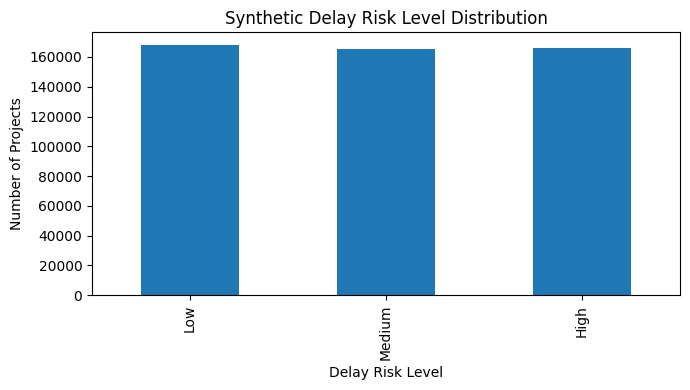

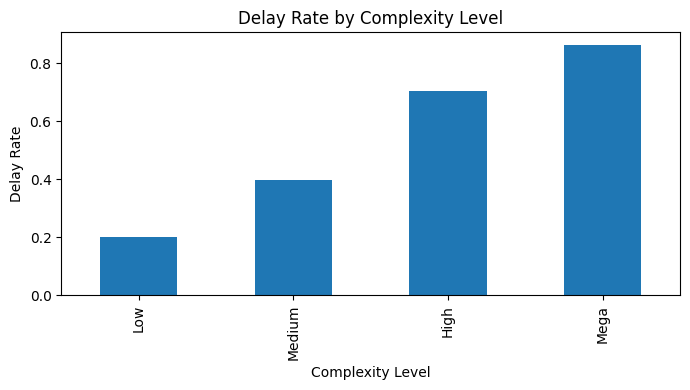

In [12]:
# =========================
# 5. Quick Visual Checks
# =========================
ax = df["Delay_Risk_Level"].value_counts().reindex(["Low", "Medium", "High"]).plot(kind="bar", figsize=(7, 4))
ax.set_title("Synthetic Delay Risk Level Distribution")
ax.set_xlabel("Delay Risk Level")
ax.set_ylabel("Number of Projects")
plt.tight_layout()
plt.show()

ax = df.groupby("Complexity_Level")["Delayed"].mean().reindex(["Low", "Medium", "High", "Mega"]).plot(kind="bar", figsize=(7, 4))
ax.set_title("Delay Rate by Complexity Level")
ax.set_xlabel("Complexity Level")
ax.set_ylabel("Delay Rate")
plt.tight_layout()
plt.show()

In [13]:
# =========================
# 6. Save Dataset, Data Dictionary, and Reproducibility Files
# =========================
dataset_path = DATA_DIR / "synthetic_project_delay_dataset.csv"
df.to_csv(dataset_path, index=False)

data_dictionary = pd.DataFrame({
    "Column": df.columns,
    "Description": [
        "Unique synthetic project ID" if c == "Project_ID" else
        "Binary synthetic target: 1 means delayed, 0 means not delayed" if c == "Delayed" else
        "Synthetic multiclass risk target: Low, Medium, High" if c == "Delay_Risk_Level" else
        "Synthetic delay probability used to generate the label" if c == "Delay_Probability_True" else
        "Generated post-target duration for descriptive analysis only" if c == "Actual_Duration_Days" else
        "Generated post-target time overrun for descriptive analysis only" if c == "Time_Overrun_Percent" else
        "Rule-based score component used during synthetic target generation" if c == "Rule_Score" else
        "Synthetic predictor generated according to generation_specification.csv"
        for c in df.columns
    ]
})
data_dictionary.to_csv(DATA_DIR / "data_dictionary.csv", index=False)

generation_specification.to_csv(DATA_DIR / "generation_specification.csv", index=False)
continuous_weights.to_csv(DATA_DIR / "target_continuous_weights.csv", index=False)
rule_adjustments.to_csv(DATA_DIR / "target_rule_adjustments.csv", index=False)

with open(DATA_DIR / "reproducibility_metadata.json", "w", encoding="utf-8") as f:
    json.dump(reproducibility_metadata, f, indent=2)

print(f"Saved dataset to: {dataset_path}")
print(f"Saved data dictionary to: {DATA_DIR / 'data_dictionary.csv'}")
print(f"Saved generation specification to: {DATA_DIR / 'generation_specification.csv'}")
print(f"Saved target weights to: {DATA_DIR / 'target_continuous_weights.csv'}")
print(f"Saved target rules to: {DATA_DIR / 'target_rule_adjustments.csv'}")
print(f"Saved reproducibility metadata to: {DATA_DIR / 'reproducibility_metadata.json'}")


# Reviewer-response audit artifacts.
generation_specification.to_csv(DATA_DIR / "FINAL_generation_specification_with_rationale.csv", index=False)
continuous_weights.to_csv(DATA_DIR / "FINAL_target_coefficient_rationale.csv", index=False)
rule_adjustments.to_csv(DATA_DIR / "FINAL_target_rule_rationale.csv", index=False)
post_target_generation_specification.to_csv(
    DATA_DIR / "FINAL_post_target_generation_specification.csv",
    index=False
)
with open(DATA_DIR / "FINAL_alternative_structural_generator.json", "w", encoding="utf-8") as f:
    json.dump(alternative_structural_generator, f, indent=2)
with open(DATA_DIR / "FINAL_artificial_prevalence_note.json", "w", encoding="utf-8") as f:
    json.dump(artificial_prevalence_note, f, indent=2)

print("Saved reviewer-response generator audit artifacts.")


Saved dataset to: C:\Users\abdul\Documents\GitHub\project-delay-risk-prediction\project_delay_outputs\data\synthetic_project_delay_dataset.csv
Saved data dictionary to: C:\Users\abdul\Documents\GitHub\project-delay-risk-prediction\project_delay_outputs\data\data_dictionary.csv
Saved generation specification to: C:\Users\abdul\Documents\GitHub\project-delay-risk-prediction\project_delay_outputs\data\generation_specification.csv
Saved target weights to: C:\Users\abdul\Documents\GitHub\project-delay-risk-prediction\project_delay_outputs\data\target_continuous_weights.csv
Saved target rules to: C:\Users\abdul\Documents\GitHub\project-delay-risk-prediction\project_delay_outputs\data\target_rule_adjustments.csv
Saved reproducibility metadata to: C:\Users\abdul\Documents\GitHub\project-delay-risk-prediction\project_delay_outputs\data\reproducibility_metadata.json
Saved reviewer-response generator audit artifacts.
